In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv("C:/Users/pooja kumari/OneDrive/Desktop/Data-Analysis-Projects/Pro-9-Bank_Fraud_Project/Fraud.csv")

print("File loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

File loaded successfully!
Shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [25]:
print("First 5 Rows")
df.head()

First 5 Rows


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [27]:
df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


In [28]:
print("===== Missing Values =====")
print(df.isnull().sum())

===== Missing Values =====
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [29]:
print("===== Duplicates =====")
print("Total Duplicates:", df.duplicated().sum())

===== Duplicates =====
Total Duplicates: 0


In [30]:
print("===== Last 5 Rows =====")
print(df.tail())

===== Last 5 Rows =====
         step      type      amount     nameOrig  oldbalanceOrg  \
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
6362615             0.0   C776919290            0.00       339682.13        1   
6362616             0.0  C1881841831            0.00            0.00        1   
6362617             0.0  C1365125890        68488.84      6379898.11        1   
6362618             0.0  C2080388513            0.00            0.00        1   
6362619             0.0   C873221189      6510099.11      7360101.63        1   

         isFlaggedFraud  
6362615               0  
6362616               0  
6362617 

In [31]:
print("===== Fraud Count =====")
print(df['isFraud'].value_counts())
print("\nFraud Percentage:")
print(df['isFraud'].value_counts(normalize=True).mul(100).round(2))

===== Fraud Count =====
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64


In [32]:
print("===== Duplicate Rows Check =====")
print("Duplicates after removing:", df.duplicated().sum())

df = df.drop_duplicates()
print("Duplicate after removing :", df.duplicated().sum())
print("Rows remaining            :", df.shape[0])

===== Duplicate Rows Check =====
Duplicates after removing: 0
Duplicate after removing : 0
Rows remaining            : 6362620


In [33]:
print("===== Data Types Check =====")
print(df.dtypes)

df['type'] = df['type'].astype('category')

print("\n===== After Fixing 'type' Column =====")
print(df['type'].dtype)
print("Uniqe Values:", df['type'].unique())

===== Data Types Check =====
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

===== After Fixing 'type' Column =====
category
Uniqe Values: ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Categories (5, object): ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


In [34]:
print("===== Columns Before Dropping ======")
print("Total columnd:", df.shape[1])
print("Column names :", list(df.columns))

df = df.drop(columns=['nameOrig', 'nameDest'])

print("\n====== Columns After Dropping =====")
print("Total columns :", df.shape[1])
print("Column names  :", list(df.columns))

===== Columns Before Dropping ======
Total columnd: 11
Column names : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

====== Columns After Dropping =====
Total columns : 9
Column names  : ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [35]:
print("====== Amount columns Sattistics =====")
print(df['amount'].describe())


Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n===== QIR Calculation =====")
print(f"Q1 (25th percentile)  : {Q1:,.2f}")
print(f"Q3 (75th percentile)  : {Q3:,.2f}")
print(f"QIR (Q3 - Q1)         :{IQR:,.2f}")
print(f"Lower Bound           :{lower_bound:,.2f}")
print(f"Upper Bound           :{upper_bound:,.2f}")


outliers = df[(df['amount'] < lower_bound) | (df['amount']>upper_bound)]

print(f"\nTotal outliers found  :{len(outliers):,}")
print(f"Outlier percentage      :{len(outliers)/len(df)*100:.2f}%")

print(f"\nFraud cases in outliers: {outliers['isFraud'].sum():,}")

    

====== Amount columns Sattistics =====
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

===== QIR Calculation =====
Q1 (25th percentile)  : 13,389.57
Q3 (75th percentile)  : 208,721.48
QIR (Q3 - Q1)         :195,331.91
Lower Bound           :-279,608.29
Upper Bound           :501,719.34

Total outliers found  :338,078
Outlier percentage      :5.31%

Fraud cases in outliers: 3,854


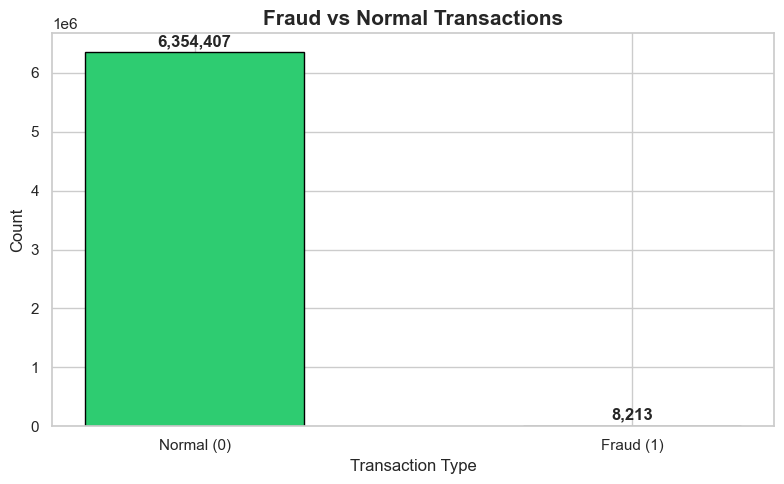

=== Fraud vs Normal Count ===
Normal (0) : 6,354,407  (99.87%)
Fraud  (1) : 8,213   (0.13%)


In [36]:
# Chart 1: Fraud vs Normal Count

fraud_counts = df['isFraud'].value_counts()
labels = ['Normal (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c']


plt.figure(figsize=(8, 5))

bars = plt.bar(labels, fraud_counts.values, color=colors, 
               edgecolor='black', width=0.5)


for bar, count in zip(bars, fraud_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 50000,
             f'{count:,}', 
             ha='center', va='bottom', 
             fontsize=12, fontweight='bold')


plt.title('Fraud vs Normal Transactions', fontsize=15, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()


print("=== Fraud vs Normal Count ===")
print(f"Normal (0) : {fraud_counts[0]:,}  ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"Fraud  (1) : {fraud_counts[1]:,}   ({fraud_counts[1]/len(df)*100:.2f}%)")

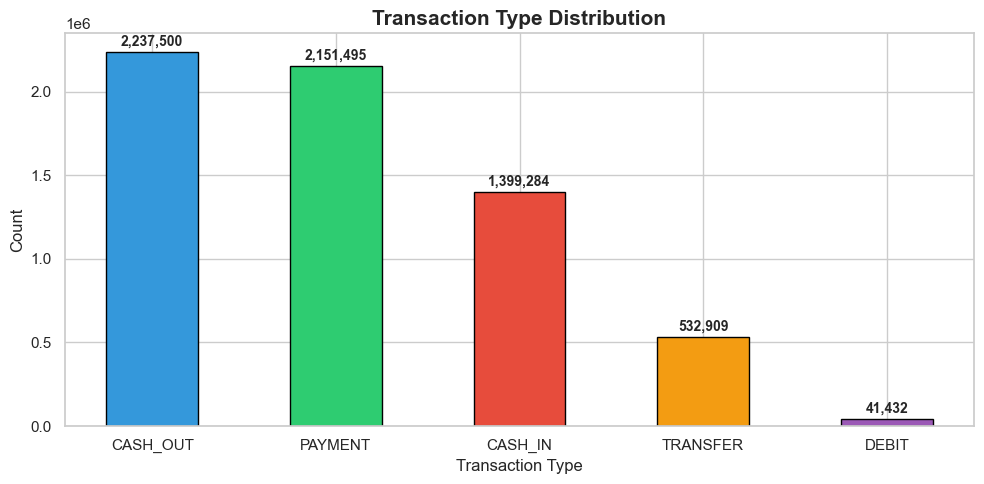

=== Transaction Type Count ===
CASH_OUT   :  2,237,500  (35.17%)
PAYMENT    :  2,151,495  (33.81%)
CASH_IN    :  1,399,284  (21.99%)
TRANSFER   :    532,909  (8.38%)
DEBIT      :     41,432  (0.65%)


In [37]:
# Chart 2: Transaction Type Distribution

type_counts = df['type'].value_counts()


colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 5))

bars = plt.bar(type_counts.index, type_counts.values, 
               color=colors, edgecolor='black', width=0.5)


for bar, count in zip(bars, type_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20000,
             f'{count:,}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')


plt.title('Transaction Type Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()


print("=== Transaction Type Count ===")
for t, c in type_counts.items():
    print(f"{t:10} : {c:>10,}  ({c/len(df)*100:.2f}%)")

=== Fraud by Transaction Type ===
    type  fraud_count  total_count  fraud_pct
CASH_OUT         4116      2237500       0.18
TRANSFER         4097       532909       0.77
 CASH_IN            0      1399284       0.00
   DEBIT            0        41432       0.00
 PAYMENT            0      2151495       0.00


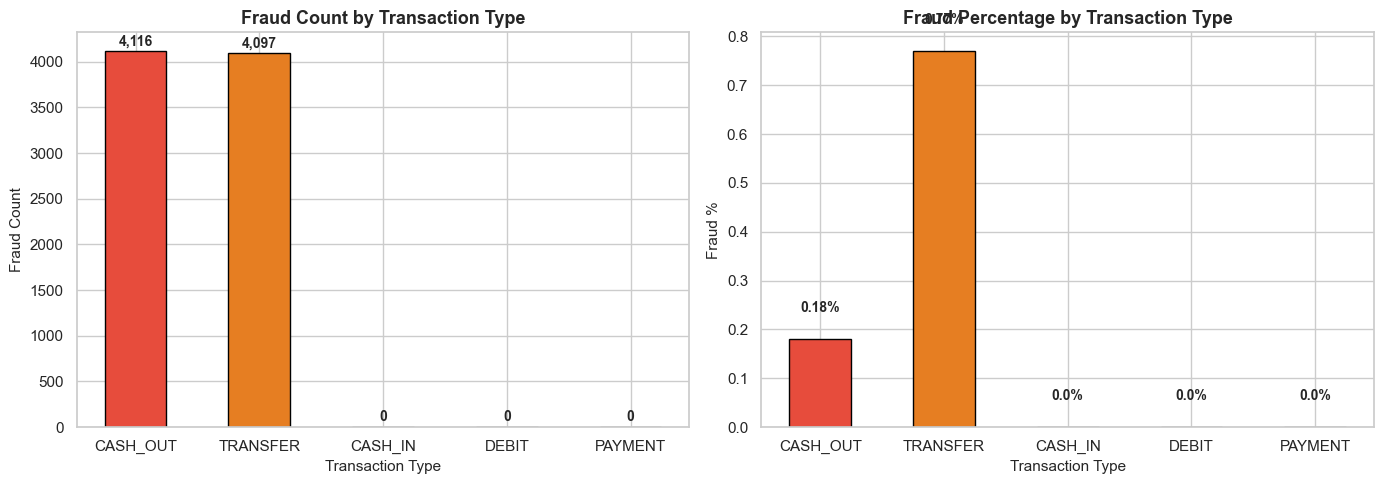

In [38]:
# Chart 3: Fraud by Transaction Type

fraud_by_type = df.groupby('type')['isFraud'].sum().reset_index()
fraud_by_type.columns = ['type', 'fraud_count']


total_by_type = df.groupby('type')['isFraud'].count().reset_index()
total_by_type.columns = ['type', 'total_count']


fraud_type_df = pd.merge(fraud_by_type, total_by_type, on='type')


fraud_type_df['fraud_pct'] = (fraud_type_df['fraud_count'] / 
                               fraud_type_df['total_count'] * 100).round(2)


fraud_type_df = fraud_type_df.sort_values('fraud_count', ascending=False)

print("=== Fraud by Transaction Type ===")
print(fraud_type_df.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#e67e22', '#95a5a6', '#95a5a6', '#95a5a6']


bars1 = axes[0].bar(fraud_type_df['type'], fraud_type_df['fraud_count'],
                     color=colors, edgecolor='black', width=0.5)

for bar, count in zip(bars1, fraud_type_df['fraud_count']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{count:,}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

axes[0].set_title('Fraud Count by Transaction Type', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=11)
axes[0].set_ylabel('Fraud Count', fontsize=11)


bars2 = axes[1].bar(fraud_type_df['type'], fraud_type_df['fraud_pct'],
                     color=colors, edgecolor='black', width=0.5)

for bar, pct in zip(bars2, fraud_type_df['fraud_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{pct}%',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

axes[1].set_title('Fraud Percentage by Transaction Type',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Type', fontsize=11)
axes[1].set_ylabel('Fraud %', fontsize=11)

plt.tight_layout()
plt.show()

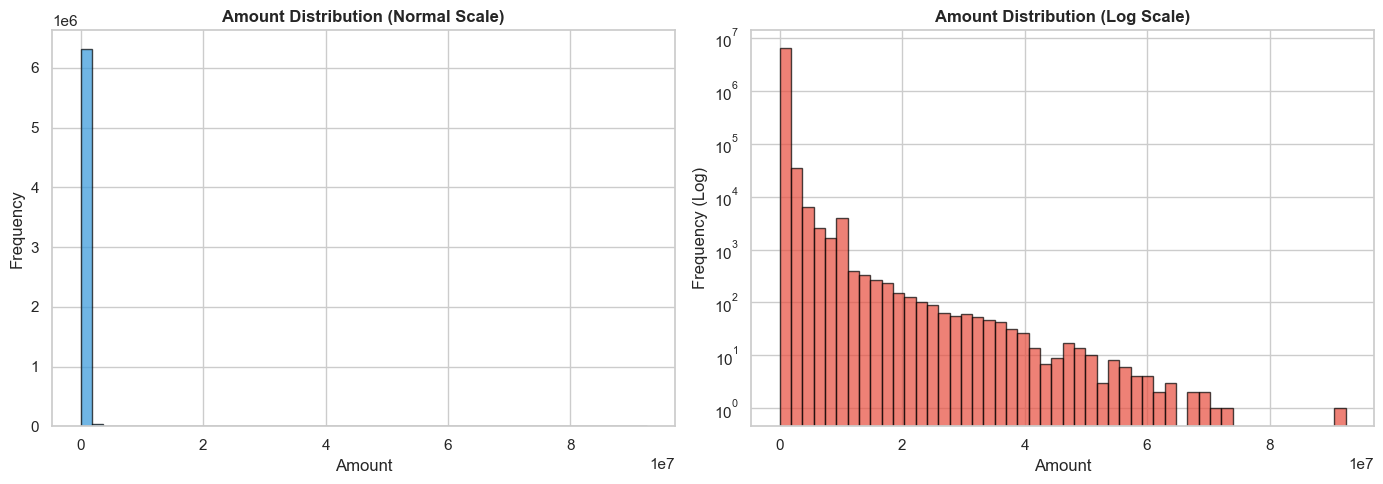

=== Amount Statistics ===
count     6362620.00
mean       179861.90
std        603858.23
min             0.00
25%         13389.57
50%         74871.94
75%        208721.48
max      92445516.64
Name: amount, dtype: float64


In [39]:
# Chart 4: Amount Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Normal Scale
axes[0].hist(df['amount'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Amount Distribution (Normal Scale)', fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Right — Log Scale
axes[1].hist(df['amount'], bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Amount Distribution (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency (Log)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("=== Amount Statistics ===")
print(df['amount'].describe().round(2))

<Figure size 800x500 with 0 Axes>

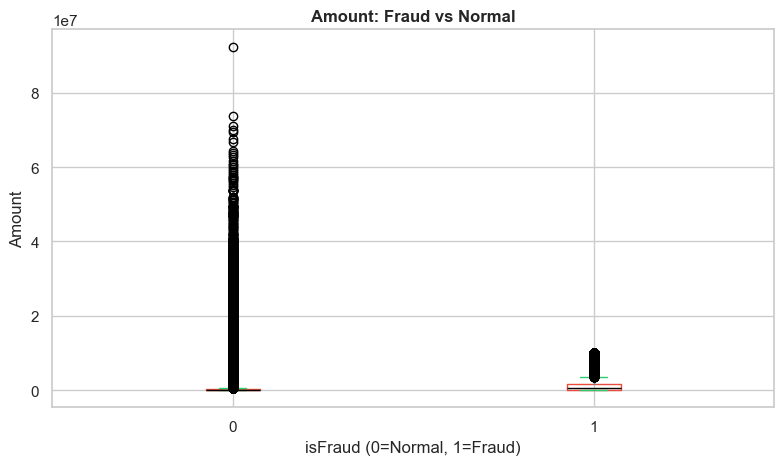

=== Average Amount: Fraud vs Normal ===
             count        mean         std   min        25%        50%  \
isFraud                                                                  
0        6354407.0   178197.04   596236.98  0.01   13368.40   74684.72   
1           8213.0  1467967.30  2404252.95  0.00  127091.33  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


In [40]:
# Chart 5: Fraud vs Normal Amount - Boxplot

plt.figure(figsize=(8, 5))

df.boxplot(column='amount', by='isFraud', 
           color=dict(boxes='#e74c3c', whiskers='#3498db', 
                      medians='black', caps='#2ecc71'),
           figsize=(8, 5))

plt.title('Amount: Fraud vs Normal', fontweight='bold')
plt.suptitle('')
plt.xlabel('isFraud (0=Normal, 1=Fraud)')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()


print("=== Average Amount: Fraud vs Normal ===")
print(df.groupby('isFraud')['amount'].describe().round(2))

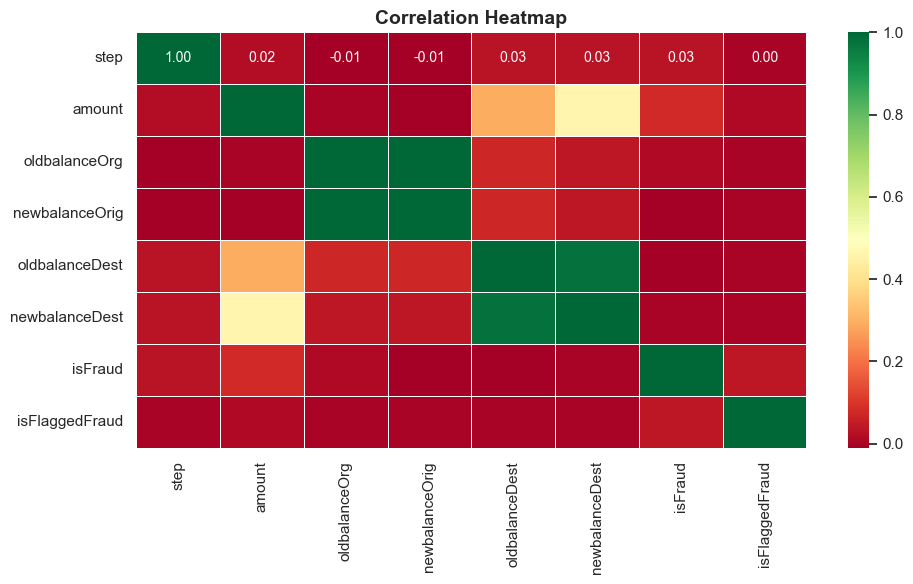

=== Correlation with isFraud ===
isFraud           1.00
amount            0.08
isFlaggedFraud    0.04
step              0.03
oldbalanceOrg     0.01
newbalanceDest    0.00
newbalanceOrig   -0.01
oldbalanceDest   -0.01
Name: isFraud, dtype: float64


In [41]:
# Chart 6: Correlation Heatmap

plt.figure(figsize=(10, 6))


corr = df.select_dtypes(include='number').corr().round(2)

sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={'size': 10})

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("=== Correlation with isFraud ===")
print(corr['isFraud'].sort_values(ascending=False))

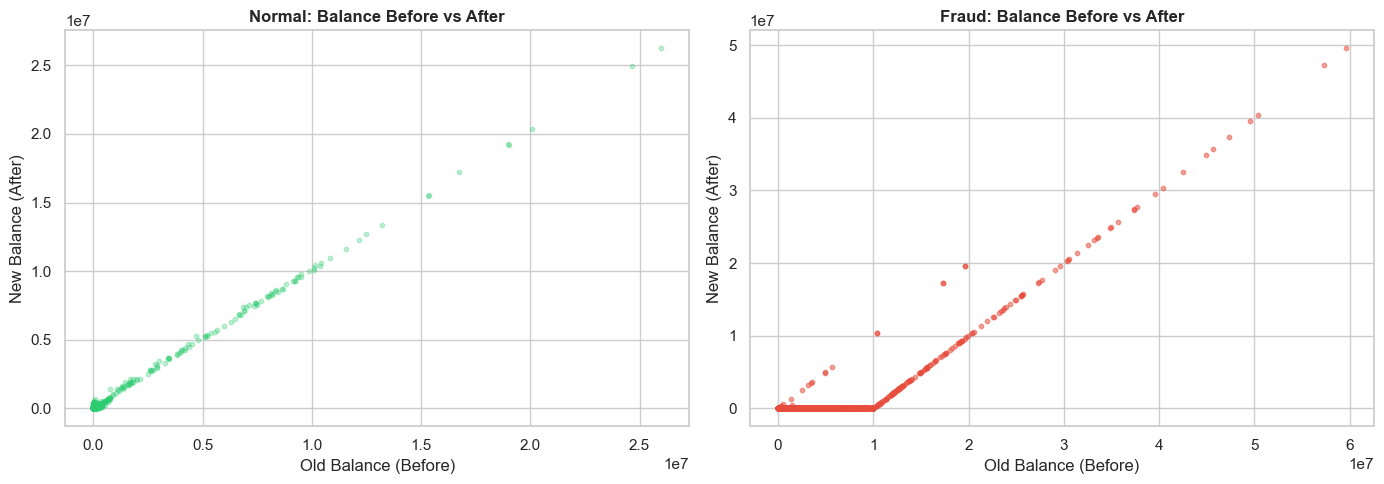

=== Balance Comparison: Fraud vs Normal ===
         oldbalanceOrg  newbalanceOrig
isFraud                               
0            832828.71       855970.23
1           1649667.61       192392.63


In [42]:
# Chart 7: Balance Before vs After

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions
normal = df[df['isFraud'] == 0].sample(1000, random_state=42)
# Fraud transactions
fraud  = df[df['isFraud'] == 1]

# Left — Normal: Balance Before vs After
axes[0].scatter(normal['oldbalanceOrg'], normal['newbalanceOrig'],
                alpha=0.3, color='#2ecc71', s=10)
axes[0].set_title('Normal: Balance Before vs After', fontweight='bold')
axes[0].set_xlabel('Old Balance (Before)')
axes[0].set_ylabel('New Balance (After)')

# Right — Fraud: Balance Before vs After
axes[1].scatter(fraud['oldbalanceOrg'], fraud['newbalanceOrig'],
                alpha=0.5, color='#e74c3c', s=10)
axes[1].set_title('Fraud: Balance Before vs After', fontweight='bold')
axes[1].set_xlabel('Old Balance (Before)')
axes[1].set_ylabel('New Balance (After)')

plt.tight_layout()
plt.show()


print("=== Balance Comparison: Fraud vs Normal ===")
print(df.groupby('isFraud')[['oldbalanceOrg', 'newbalanceOrig']].mean().round(2))

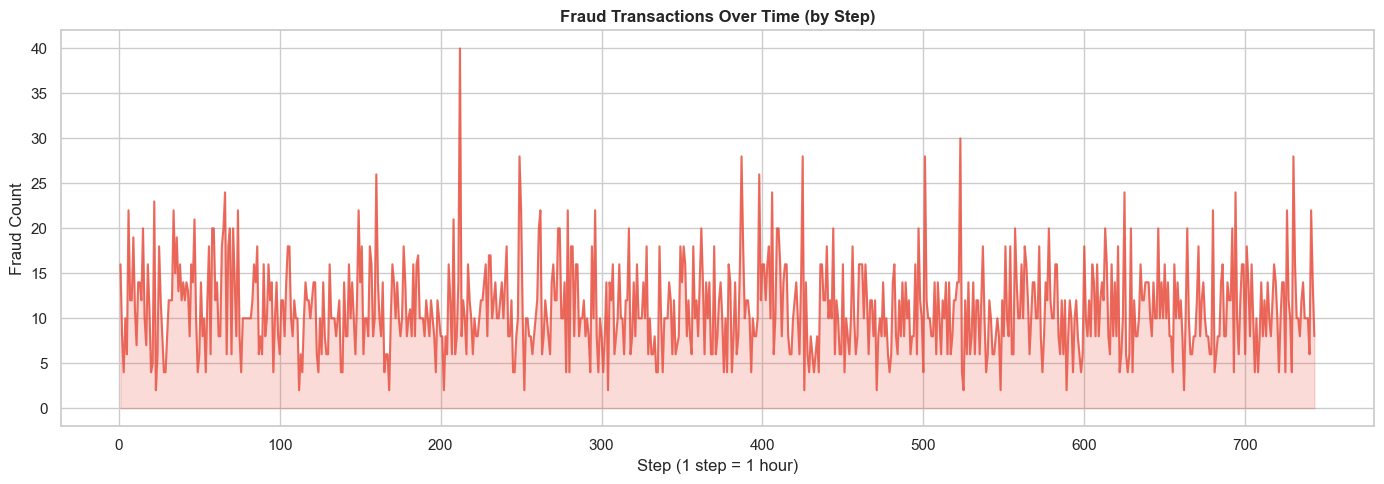

=== Fraud by Time ===
Peak fraud step  : 212 (hour)
Peak fraud count : 40
Avg fraud/step   : 11.08


In [43]:
# Chart 8: Fraud by Step/Time

fraud_by_step = df[df['isFraud'] == 1].groupby('step')['isFraud'].count()

plt.figure(figsize=(14, 5))

plt.plot(fraud_by_step.index, fraud_by_step.values,
         color='#e74c3c', linewidth=1.5, alpha=0.8)

plt.fill_between(fraud_by_step.index, fraud_by_step.values,
                 alpha=0.2, color='#e74c3c')

plt.title('Fraud Transactions Over Time (by Step)', fontweight='bold')
plt.xlabel('Step (1 step = 1 hour)')
plt.ylabel('Fraud Count')
plt.tight_layout()
plt.show()

print("=== Fraud by Time ===")
print(f"Peak fraud step  : {fraud_by_step.idxmax()} (hour)")
print(f"Peak fraud count : {fraud_by_step.max()}")
print(f"Avg fraud/step   : {fraud_by_step.mean():.2f}")

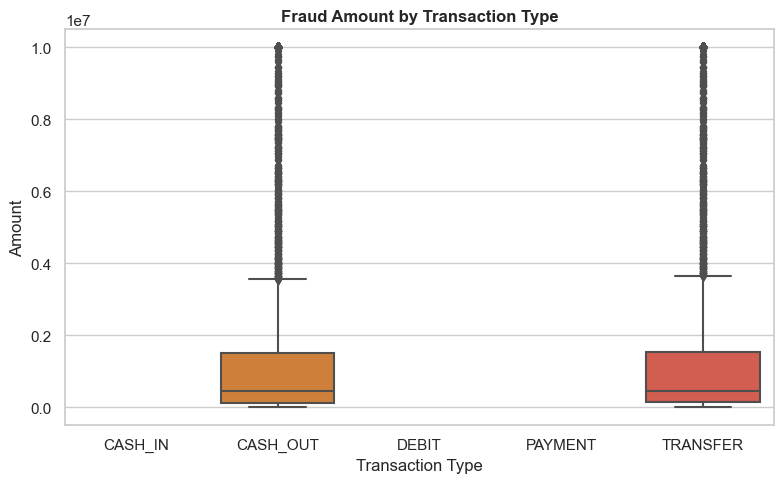

=== Fraud Amount Stats by Type ===
           count        mean         std   min        25%        50%  \
type                                                                   
CASH_IN      0.0         NaN         NaN   NaN        NaN        NaN   
CASH_OUT  4116.0  1455102.59  2393841.79   0.0  125464.45  435516.90   
DEBIT        0.0         NaN         NaN   NaN        NaN        NaN   
PAYMENT      0.0         NaN         NaN   NaN        NaN        NaN   
TRANSFER  4097.0  1480891.67  2414890.38  63.8  128417.96  445705.76   

                 75%         max  
type                              
CASH_IN          NaN         NaN  
CASH_OUT  1500761.03  10000000.0  
DEBIT            NaN         NaN  
PAYMENT          NaN         NaN  
TRANSFER  1534985.07  10000000.0  


In [44]:
# Chart 9: Fraud Amount by Transaction Type

fraud_df = df[df['isFraud'] == 1]

plt.figure(figsize=(8, 5))

sns.boxplot(data=fraud_df, x='type', y='amount',
            palette=['#e74c3c', '#e67e22'])

plt.title('Fraud Amount by Transaction Type', fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

print("=== Fraud Amount Stats by Type ===")
print(fraud_df.groupby('type')['amount'].describe().round(2))

=== isFlaggedFraud vs isFraud ===
        Not Flagged  Flagged
Normal      6354407        0
Fraud          8197       16

=== Fraud Caught by Bank System ===
Total Fraud      : 8,213
Flagged (Caught) : 16  (0.19%)
Not Flagged(Missed): 8,197 (99.81%)


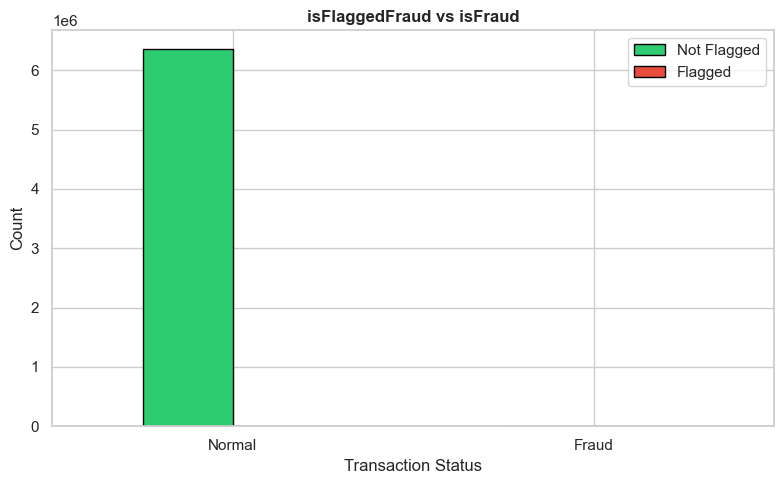

In [45]:
# Chart 10: isFlaggedFraud vs isFraud

cross = pd.crosstab(df['isFraud'], df['isFlaggedFraud'])
cross.index = ['Normal', 'Fraud']
cross.columns = ['Not Flagged', 'Flagged']

print("=== isFlaggedFraud vs isFraud ===")
print(cross)

# Percentage
print("\n=== Fraud Caught by Bank System ===")
total_fraud = df['isFraud'].sum()
caught = df[(df['isFraud']==1) & (df['isFlaggedFraud']==1)].shape[0]
missed = df[(df['isFraud']==1) & (df['isFlaggedFraud']==0)].shape[0]

print(f"Total Fraud      : {total_fraud:,}")
print(f"Flagged (Caught) : {caught:,}  ({caught/total_fraud*100:.2f}%)")
print(f"Not Flagged(Missed): {missed:,} ({missed/total_fraud*100:.2f}%)")

# Plot
cross.plot(kind='bar', color=['#2ecc71', '#e74c3c'],
           edgecolor='black', figsize=(8, 5))
plt.title('isFlaggedFraud vs isFraud', fontweight='bold')
plt.xlabel('Transaction Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== Zero Balance Pattern in Fraud ===
Zero Balance    : 8,053  (98.05%)
Non-Zero Balance: 160  (1.95%)


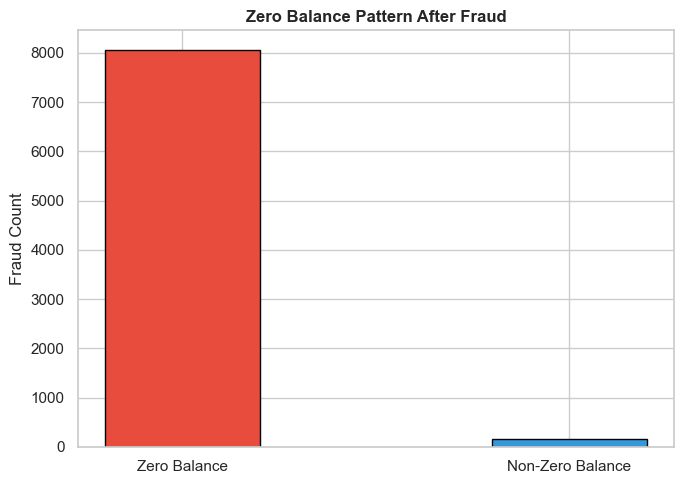

In [46]:
# Chart 11: Zero Balance Pattern in Fraud


fraud_df = df[df['isFraud'] == 1]

zero    = (fraud_df['newbalanceOrig'] == 0).sum()
nonzero = (fraud_df['newbalanceOrig'] != 0).sum()
total   = len(fraud_df)

print("=== Zero Balance Pattern in Fraud ===")
print(f"Zero Balance    : {zero:,}  ({zero/total*100:.2f}%)")
print(f"Non-Zero Balance: {nonzero:,}  ({nonzero/total*100:.2f}%)")

# Plot
plt.figure(figsize=(7, 5))
plt.bar(['Zero Balance', 'Non-Zero Balance'], [zero, nonzero],
        color=['#e74c3c', '#3498db'], edgecolor='black', width=0.4)
plt.title('Zero Balance Pattern After Fraud', fontweight='bold')
plt.ylabel('Fraud Count')
plt.tight_layout()
plt.show()

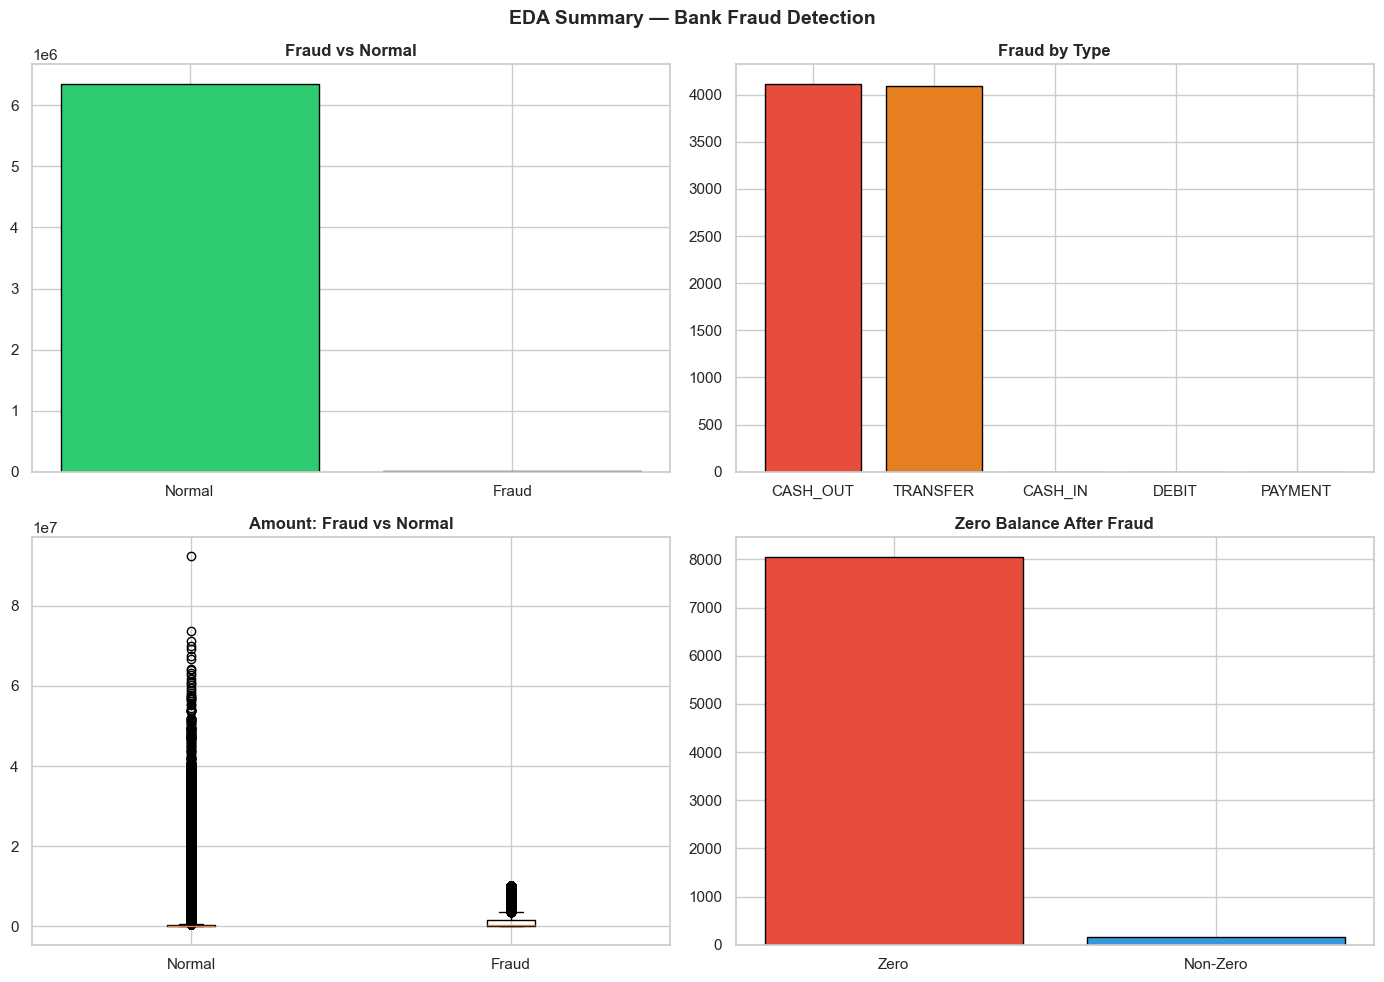

- EDA Complete!


In [47]:
# Chart 12: EDA Summary

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fraud vs Normal
axes[0,0].bar(['Normal', 'Fraud'], df['isFraud'].value_counts().values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0,0].set_title('Fraud vs Normal', fontweight='bold')

# 2. Fraud by Type
fraud_type = df[df['isFraud']==1]['type'].value_counts()
axes[0,1].bar(fraud_type.index, fraud_type.values,
               color=['#e74c3c','#e67e22'], edgecolor='black')
axes[0,1].set_title('Fraud by Type', fontweight='bold')

# 3. Amount Boxplot
axes[1,0].boxplot([df[df['isFraud']==0]['amount'],
                   df[df['isFraud']==1]['amount']],
                   labels=['Normal','Fraud'])
axes[1,0].set_title('Amount: Fraud vs Normal', fontweight='bold')

# 4. Zero Balance
axes[1,1].bar(['Zero','Non-Zero'], [8053, 160],
               color=['#e74c3c','#3498db'], edgecolor='black')
axes[1,1].set_title('Zero Balance After Fraud', fontweight='bold')

plt.suptitle('EDA Summary — Bank Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("- EDA Complete!")

In [51]:

save_path = r"C:/Users/pooja kumari/OneDrive/Desktop/Data-Analysis-Projects/Pro-9-Bank_Fraud_Project/fraud_cleaned.csv"
df.to_csv(save_path, index=False)

print("File saved successfully!")
print(f"Location : {save_path}")
print(f"Rows     : {df.shape[0]:,}")
print(f"Columns  : {df.shape[1]}")

File saved successfully!
Location : C:/Users/pooja kumari/OneDrive/Desktop/Data-Analysis-Projects/Pro-9-Bank_Fraud_Project/fraud_cleaned.csv
Rows     : 6,362,620
Columns  : 9
